Total observations (T): 7522
Failed windows: 0 / 7272
NaN in VaR:     0
Aligned sizes — dates: 7272, L: 7272, VaR: 7272

Exceedance ratio alpha_hat : 0.0133
Expected (1 - alpha)       : 0.0100
Number of exceedances      : 97


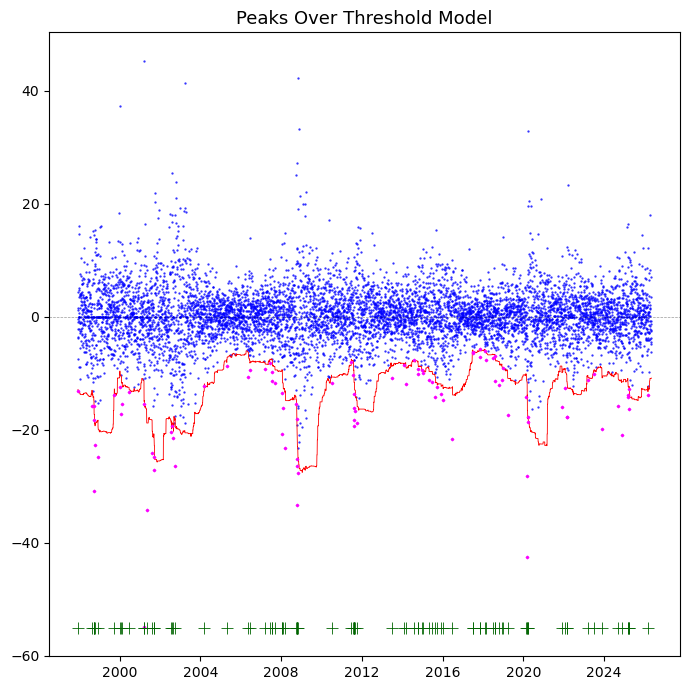

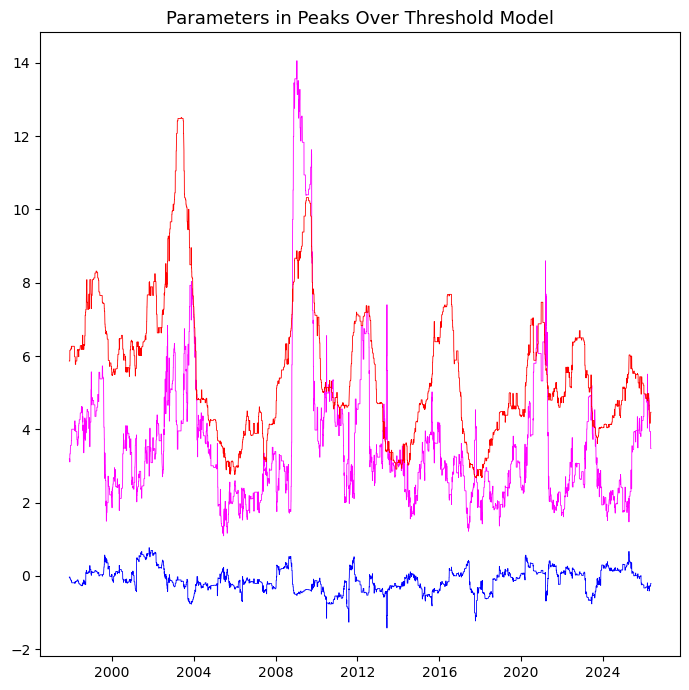

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genpareto          # GPD instead of GEV

# ── 1. Load data ─────────────────────────────────────────────────
r_bayer = pd.read_csv("../Data/BAYN_DE_log_returns.csv",
                      parse_dates=["Date"]).set_index("Date")["Close"]
r_bmw = pd.read_csv("../Data/BMW_DE_log_returns.csv",
                    parse_dates=["Date"]).set_index("Date")["Close"]
r_bmw.index = pd.to_datetime(r_bmw.index, format="%d.%m.%Y")
r_sie = pd.read_csv("../Data/SIE_DE_log_returns.csv",
                    parse_dates=["Date"]).set_index("Date")["Close"]
r_sie.index = pd.to_datetime(r_sie.index, format="%d.%m.%Y")

returns = pd.concat([r_bayer, r_bmw, r_sie], axis=1)
returns.columns = ["Bayer", "BMW", "Siemens"]
returns = returns.dropna()

dates = returns.index.to_numpy()
x     = returns.sum(axis=1).values * 100
Obs   = len(x)
print(f"Total observations (T): {Obs}")

# ── 2. Parameters ────────────────────────────────────────────────
w     = 250    # rolling window size
alpha = 0.99   # VaR confidence level => exceedance ratio = 1%
q_thr = 0.90   # threshold quantile: top 10% of losses are exceedances

L = -x         # loss series: positive = loss

# ── 3. POT VaR function ───────────────────────────────────────────
def pot_var(L_window, q_thr, alpha):
    n   = len(L_window)
    u   = np.quantile(L_window, q_thr)        # threshold u

    exceedances = L_window[L_window > u] - u  # Y_i = L_i - u  (excess losses)
    N_u = len(exceedances)

    if N_u < 10:
        raise ValueError(f"Too few exceedances: N_u={N_u}")

    # GPD MLE: shape xi=c, loc fixed at 0, scale beta
    c, _, beta = genpareto.fit(exceedances, floc=0)
    xi = c

    if np.isnan(xi) or np.isnan(beta) or beta <= 0 or np.abs(xi) > 10:
        raise ValueError("Degenerate GPD fit")

    tail_prob = (n / N_u) * (1 - alpha)    # rescaled tail probability

    if tail_prob <= 0:
        raise ValueError("Tail probability <= 0")

    if abs(xi) > 1e-6:
        var_loss = u + (beta / xi) * (tail_prob ** (-xi) - 1)
    else:
        var_loss = u - beta * np.log(tail_prob)

    return {"var_loss": var_loss, "xi": xi, "beta": beta, "u": u}

# ── 4. Rolling estimation ────────────────────────────────────────
n_roll  = Obs - w
results = {k: np.full(n_roll, np.nan) for k in ["var_loss", "xi", "beta", "u"]}

fail_count = 0
for i in range(n_roll):
    L_window = L[i:i + w]
    try:
        out = pot_var(L_window, q_thr, alpha)
        for k in results:
            results[k][i] = out[k]
    except Exception:
        fail_count += 1

print(f"Failed windows: {fail_count} / {n_roll}")
print(f"NaN in VaR:     {np.isnan(results['var_loss']).sum()}")

VaR_series = -results["var_loss"]

# ── 5. Align with next-day realizations ──────────────────────────
dates_plot = dates[w: w + n_roll]
L_plot     = x[w: w + n_roll]

assert len(dates_plot) == n_roll
assert len(L_plot)     == n_roll
assert len(VaR_series) == n_roll
print(f"Aligned sizes — dates: {len(dates_plot)}, L: {len(L_plot)}, VaR: {len(VaR_series)}")

# ── 6. Backtesting: exceedance ratio ─────────────────────────────
exceed    = L_plot < VaR_series
alpha_hat = exceed.sum() / n_roll

print(f"\nExceedance ratio alpha_hat : {alpha_hat:.4f}")
print(f"Expected (1 - alpha)       : {1 - alpha:.4f}")
print(f"Number of exceedances      : {exceed.sum()}")

K            = np.where(exceed)[0]
dates_exceed = dates_plot[K]
L_exceed     = L_plot[K]
yplus        = np.full(len(K), np.nanmin(L_plot) - 0.2)

# ── 7. Plot: VaR backtest ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(dates_plot, L_plot, color="blue", marker="D",
           s=0.5, alpha=0.6, label="Profit/Loss", zorder=2)
ax.plot(dates_plot, VaR_series, color="red", linewidth=0.6,
        label="VaR (99%)", zorder=3)
ax.scatter(dates_exceed, L_exceed, color="magenta", marker="D",
           s=1.5, label=f"Exceedances ({exceed.sum()})", zorder=4)
ax.scatter(dates_exceed, yplus, color="darkgreen", marker="+",
           s=70, linewidths=0.6, zorder=4)

ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.4)
ax.set_title("Peaks Over Threshold Model", fontsize=13)

ax.grid(False)

plt.tight_layout()
plt.savefig("pot_var.png", dpi=200, transparent=True, bbox_inches="tight")
plt.show()

# ── 8. Plot: rolling GPD parameters ──────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 7))

ax2.plot(dates_plot, results["xi"],   color="blue",    linewidth=0.6,
         label="Shape parameter (ξ)")
ax2.plot(dates_plot, results["beta"], color="magenta", linewidth=0.6,
         label="Scale parameter (β)")
ax2.plot(dates_plot, results["u"],    color="red",     linewidth=0.6,
         label="Threshold (u)")

ax2.set_title("Parameters in Peaks Over Threshold Model", fontsize=13)
ax2.grid(False)

plt.tight_layout()
plt.savefig("pot_gpd_parameters.png", dpi=200, transparent=True, bbox_inches="tight")
plt.show()

# # ── 9. Save outputs ──────────────────────────────────────────────
# pd.DataFrame({
#     "Date":        dates_plot,
#     "VaR":         VaR_series,
#     "PnL":         L_plot,
#     "Exceedance":  exceed.astype(int),
#     "shape_xi":    results["xi"],
#     "scale_beta":  results["beta"],
#     "threshold_u": results["u"],
# }).to_csv("pot_results.csv", index=False)

# np.savetxt("pot_shape_xi.txt",    results["xi"])
# np.savetxt("pot_scale_beta.txt",  results["beta"])
# np.savetxt("pot_threshold_u.txt", results["u"])
# print("Saved: pot_results.csv + parameter .txt files")

**Cell 1 — Imports and configuration**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genpareto

BASE_DIR = "../Data"
OUTPUT_DIR = os.getcwd()

BAYER_CSV = os.path.join(BASE_DIR, "BAYN_DE_log_returns.csv")
BMW_CSV = os.path.join(BASE_DIR, "BMW_DE_log_returns.csv")
SIE_CSV = os.path.join(BASE_DIR, "SIE_DE_log_returns.csv")

W = 250          # rolling window size
Q_THR = 0.90     # threshold quantile: top 10% of losses are exceedances

**Cell 2 — Load and combine returns**

In [2]:
r_bayer = pd.read_csv(BAYER_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
r_bmw = pd.read_csv(BMW_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
r_sie = pd.read_csv(SIE_CSV, parse_dates=["Date"]).set_index("Date")["Close"]

returns = pd.concat([r_bayer, r_bmw, r_sie], axis=1)
returns.columns = ["Bayer", "BMW", "Siemens"]
returns = returns.dropna()

dates = returns.index.to_numpy()
x = returns.sum(axis=1).values * 100   # portfolio P&L, percentage scale
L = -x                                  # loss series: positive = loss
Obs = len(x)
print(f"Total observations (T): {Obs}")

Total observations (T): 7522


**Cell 3 — POT VaR fitting function**

In [3]:
def pot_var(L_window, q_thr, alpha):
    n = len(L_window)
    u = np.quantile(L_window, q_thr)

    exceedances = L_window[L_window > u] - u
    N_u = len(exceedances)

    if N_u < 10:
        raise ValueError(f"Too few exceedances: N_u={N_u}")

    xi, _, beta = genpareto.fit(exceedances, floc=0)

    if np.isnan(xi) or np.isnan(beta) or beta <= 0 or np.abs(xi) > 10:
        raise ValueError("Degenerate GPD fit")

    tail_prob = (n / N_u) * (1 - alpha)
    if tail_prob <= 0:
        raise ValueError("Tail probability <= 0")
    if tail_prob > 1:
        raise ValueError("Tail probability > 1: extrapolation out of range")

    if abs(xi) > 1e-6:
        var_loss = u + (beta / xi) * (tail_prob ** (-xi) - 1)
    else:
        var_loss = u - beta * np.log(tail_prob)

    return {"var_loss": var_loss, "xi": xi, "beta": beta, "u": u}

**Cell 4 — Rolling estimation and backtest (reusable function)**

In [4]:
def run_rolling_pot(x, L, dates, alpha, q_thr=Q_THR, w=W):
    Obs = len(x)
    n_roll = Obs - w
    results = {key: np.full(n_roll, np.nan) for key in ["var_loss", "xi", "beta", "u"]}

    fail_count = 0
    for i in range(n_roll):
        L_window = L[i:i + w]
        try:
            out = pot_var(L_window, q_thr, alpha)
            for key in results:
                results[key][i] = out[key]
        except Exception:
            fail_count += 1

    print(f"[alpha={alpha}] Failed windows: {fail_count} / {n_roll}")
    print(f"[alpha={alpha}] NaN in VaR: {np.isnan(results['var_loss']).sum()}")

    VaR_series = -results["var_loss"]
    dates_plot = dates[w:w + n_roll]
    L_plot = x[w:w + n_roll]

    assert len(dates_plot) == n_roll == len(L_plot) == len(VaR_series)

    exceed = L_plot < VaR_series
    alpha_hat = exceed.sum() / n_roll

    print(f"[alpha={alpha}] Exceedance ratio alpha_hat: {alpha_hat:.4f}")
    print(f"[alpha={alpha}] Expected (1 - alpha):       {1 - alpha:.4f}")
    print(f"[alpha={alpha}] Number of exceedances:      {exceed.sum()}")

    return dates_plot, L_plot, VaR_series, exceed, results

**Cell 5 — Plotting function (VaR backtest + GPD parameters)**

In [17]:
def plot_pot_backtest(dates_plot, L_plot, VaR_series, exceed, results, alpha, suffix):
    idx_exceed = np.where(exceed)[0]
    dates_exceed = dates_plot[idx_exceed]
    L_exceed = L_plot[idx_exceed]
    yplus = np.full(len(idx_exceed), np.nanmin(L_plot) - 0.2)

    conf_pct = f"{alpha * 100:.0f}%"

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(dates_plot, L_plot, color="blue", marker="D", s=0.5, alpha=0.6, label="Profit/Loss", zorder=2)
    ax.plot(dates_plot, VaR_series, color="red", linewidth=1, label=f"VaR ({conf_pct})", zorder=3)
    ax.scatter(dates_exceed, L_exceed, color="magenta", marker="D", s=3,
               label=f"Exceedances ({exceed.sum()})", zorder=4)
    ax.scatter(dates_exceed, yplus, color="darkgreen", marker="+", s=70, linewidths=0.6, zorder=4)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.4)
    ax.set_title("Peaks Over Threshold Model", fontsize=13)
    ax.grid(False)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"pot_var_{suffix}.png"),
                dpi=200, transparent=True, bbox_inches="tight")
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(7, 7))
    ax2.plot(dates_plot, results["xi"], color="blue", linewidth=2, label="Shape parameter (xi)")
    ax2.plot(dates_plot, results["beta"], color="magenta", linewidth=2, label="Scale parameter (beta)")
    ax2.plot(dates_plot, results["u"], color="red", linewidth=2, label="Threshold (u)")
    ax2.set_title("Parameters in Peaks Over Threshold Model", fontsize=13)
    ax2.grid(False)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"pot_gpd_parameters_{suffix}.png"),
                dpi=200, transparent=True, bbox_inches="tight")
    plt.show()

**Cell 6 — Run for alpha = 0.99 (1% VaR)**

[alpha=0.99] Failed windows: 0 / 7272
[alpha=0.99] NaN in VaR: 0
[alpha=0.99] Exceedance ratio alpha_hat: 0.0133
[alpha=0.99] Expected (1 - alpha):       0.0100
[alpha=0.99] Number of exceedances:      97


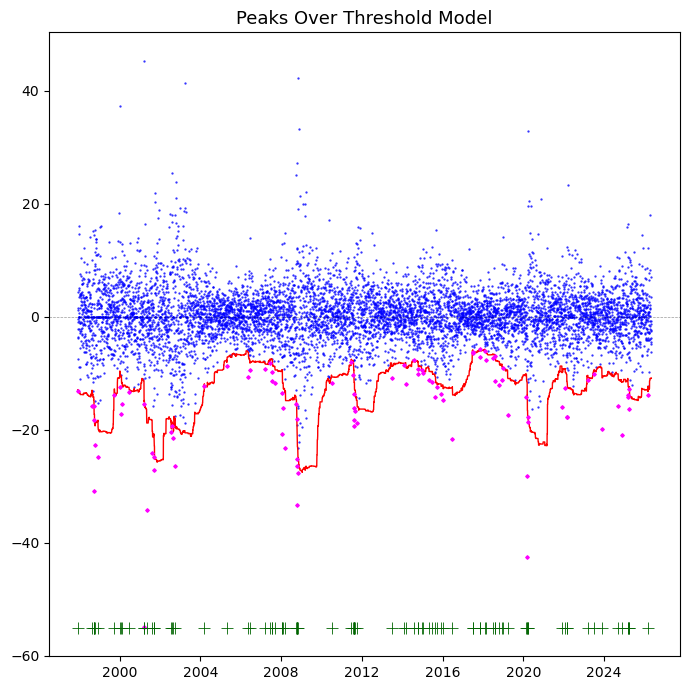

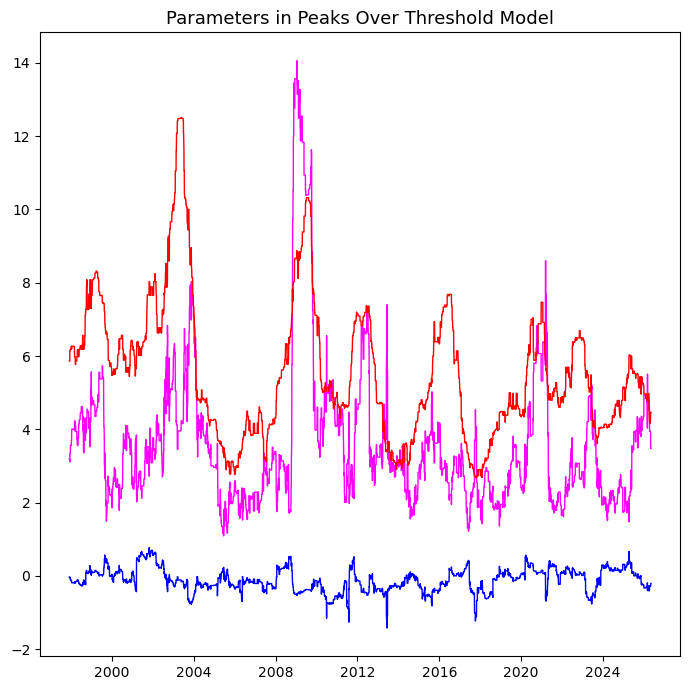

In [13]:
dates_99, L_99, VaR_99, exceed_99, results_99 = run_rolling_pot(x, L, dates, alpha=0.99)
plot_pot_backtest(dates_99, L_99, VaR_99, exceed_99, results_99, alpha=0.99, suffix="99")

**Cell 6 — Run for alpha = 0.95 (5% VaR)**

[alpha=0.95] Failed windows: 0 / 7272
[alpha=0.95] NaN in VaR: 0
[alpha=0.95] Exceedance ratio alpha_hat: 0.0553
[alpha=0.95] Expected (1 - alpha):       0.0500
[alpha=0.95] Number of exceedances:      402


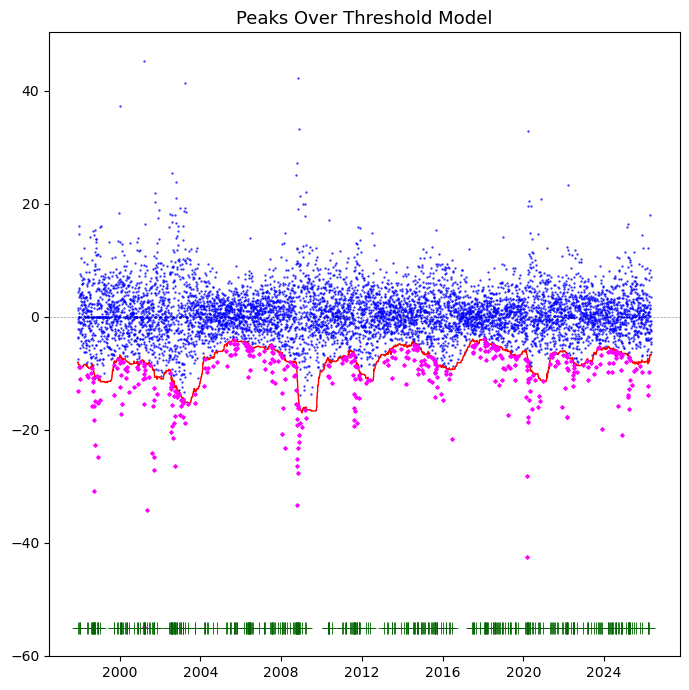

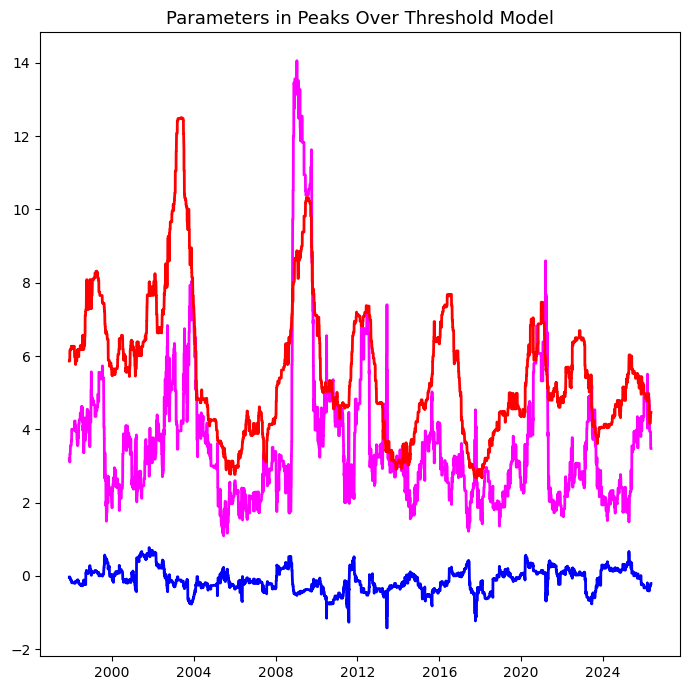

In [18]:
dates_95, L_95, VaR_95, exceed_95, results_95 = run_rolling_pot(x, L, dates, alpha=0.95)
plot_pot_backtest(dates_95, L_95, VaR_95, exceed_95, results_95, alpha=0.95, suffix="95")

**Cell 7 — Save outputs (optional, uncomment to run)**

In [ ]:
# pd.DataFrame({
#     "Date": dates_99, "VaR": VaR_99, "PnL": L_99,
#     "Exceedance": exceed_99.astype(int),
#     "shape_xi": results_99["xi"],
#     "scale_beta": results_99["beta"],
#     "threshold_u": results_99["u"],
# }).to_csv(os.path.join(OUTPUT_DIR, "pot_results_99.csv"), index=False)